In [3]:
# !python3 -m pip install -qU ap_res_external_docchecker_protos --index-url https://nexus.ap-team.ru/repository/pypi/simple
# !python3 -m pip install -qU ap_res_nlp_machinegenerated_protos --index-url https://nexus.ap-team.ru/repository/pypi/simple

In [6]:
TXT   = "data/txt_texts/text2.txt"
with open(TXT, 'r', encoding='utf-8') as file:
    text = file.read()

In [7]:
from ap_res_external_docchecker_protos.client import Client as CheckerClient
from ap_res_utils.guid_utils import uuid_to_hi_lo, doc_node_id_to_uuid, hi_lo_to_uuid
import uuid

CHECKER_URL = "https://elibrary-paraphrase.internal.k8s.antiplagiat.ru/"
paraphrase_client = CheckerClient([CHECKER_URL])

DOCHECKER_URL = 'https://docchecker-elib-1.internal.k8s.antiplagiat.ru/'
dochecker_client = CheckerClient([DOCHECKER_URL])

predict = dochecker_client.check_text(request_guid=[1,1],
                            doc_guid=[1,1],
                            text=text,
                            text_langs=['ru'],
                            collection_langs=['ru'],
                            max_sources_count=10,
                            index_usage_mode='Full',
                            pair_comparing_usage='StrictFuzzy',
                            data_range=(1, (365*24*60*60)*3000))

predict_sources = [str(hi_lo_to_uuid(int(src['SrcId']['Hi']), int(src['SrcId']['Lo']))) for src in predict['Sources']]
pr_percent = predict['Originality']

predict_paraphrase_client = paraphrase_client.check_text(
       request_guid=[1,1],
        doc_guid=[1,1],
        text=text,
        text_langs=['ru'],
        collection_langs=['ru'],
        )

In [8]:
predict

{'Originality': 1.0,
 'RequestId': {'Hi': '1', 'Lo': '1'},
 'Statistics': {'FullTime': '0.466365600s',
  'WaitInQueue': '0s',
  'SearchByIndex': '0.463206600s',
  'LoadMetadata': '0s',
  'LoadTexts': '0s',
  'CompareTexts': '0s',
  'ProcessText': '0.003058s',
  'ProcessCharsCount': 2181,
  'LoadTextsBatches': []},
 'Sources': []}

In [9]:
predict_paraphrase_client

{'Originality': 1.0, 'RequestId': {'Hi': '1', 'Lo': '1'}, 'Sources': []}

In [10]:
from ap_res_nlp_machinegenerated_protos.client import Client as SampleClient
client_machinegen = SampleClient(["https://entrypoint-machinegenerated.internal.k8s.antiplagiat.ru"])
sample_metadata = (("key1", "query1"),)
client_machinegen.check_text("test", text, "ru", threshold=0.98)

[(0, 2181)]

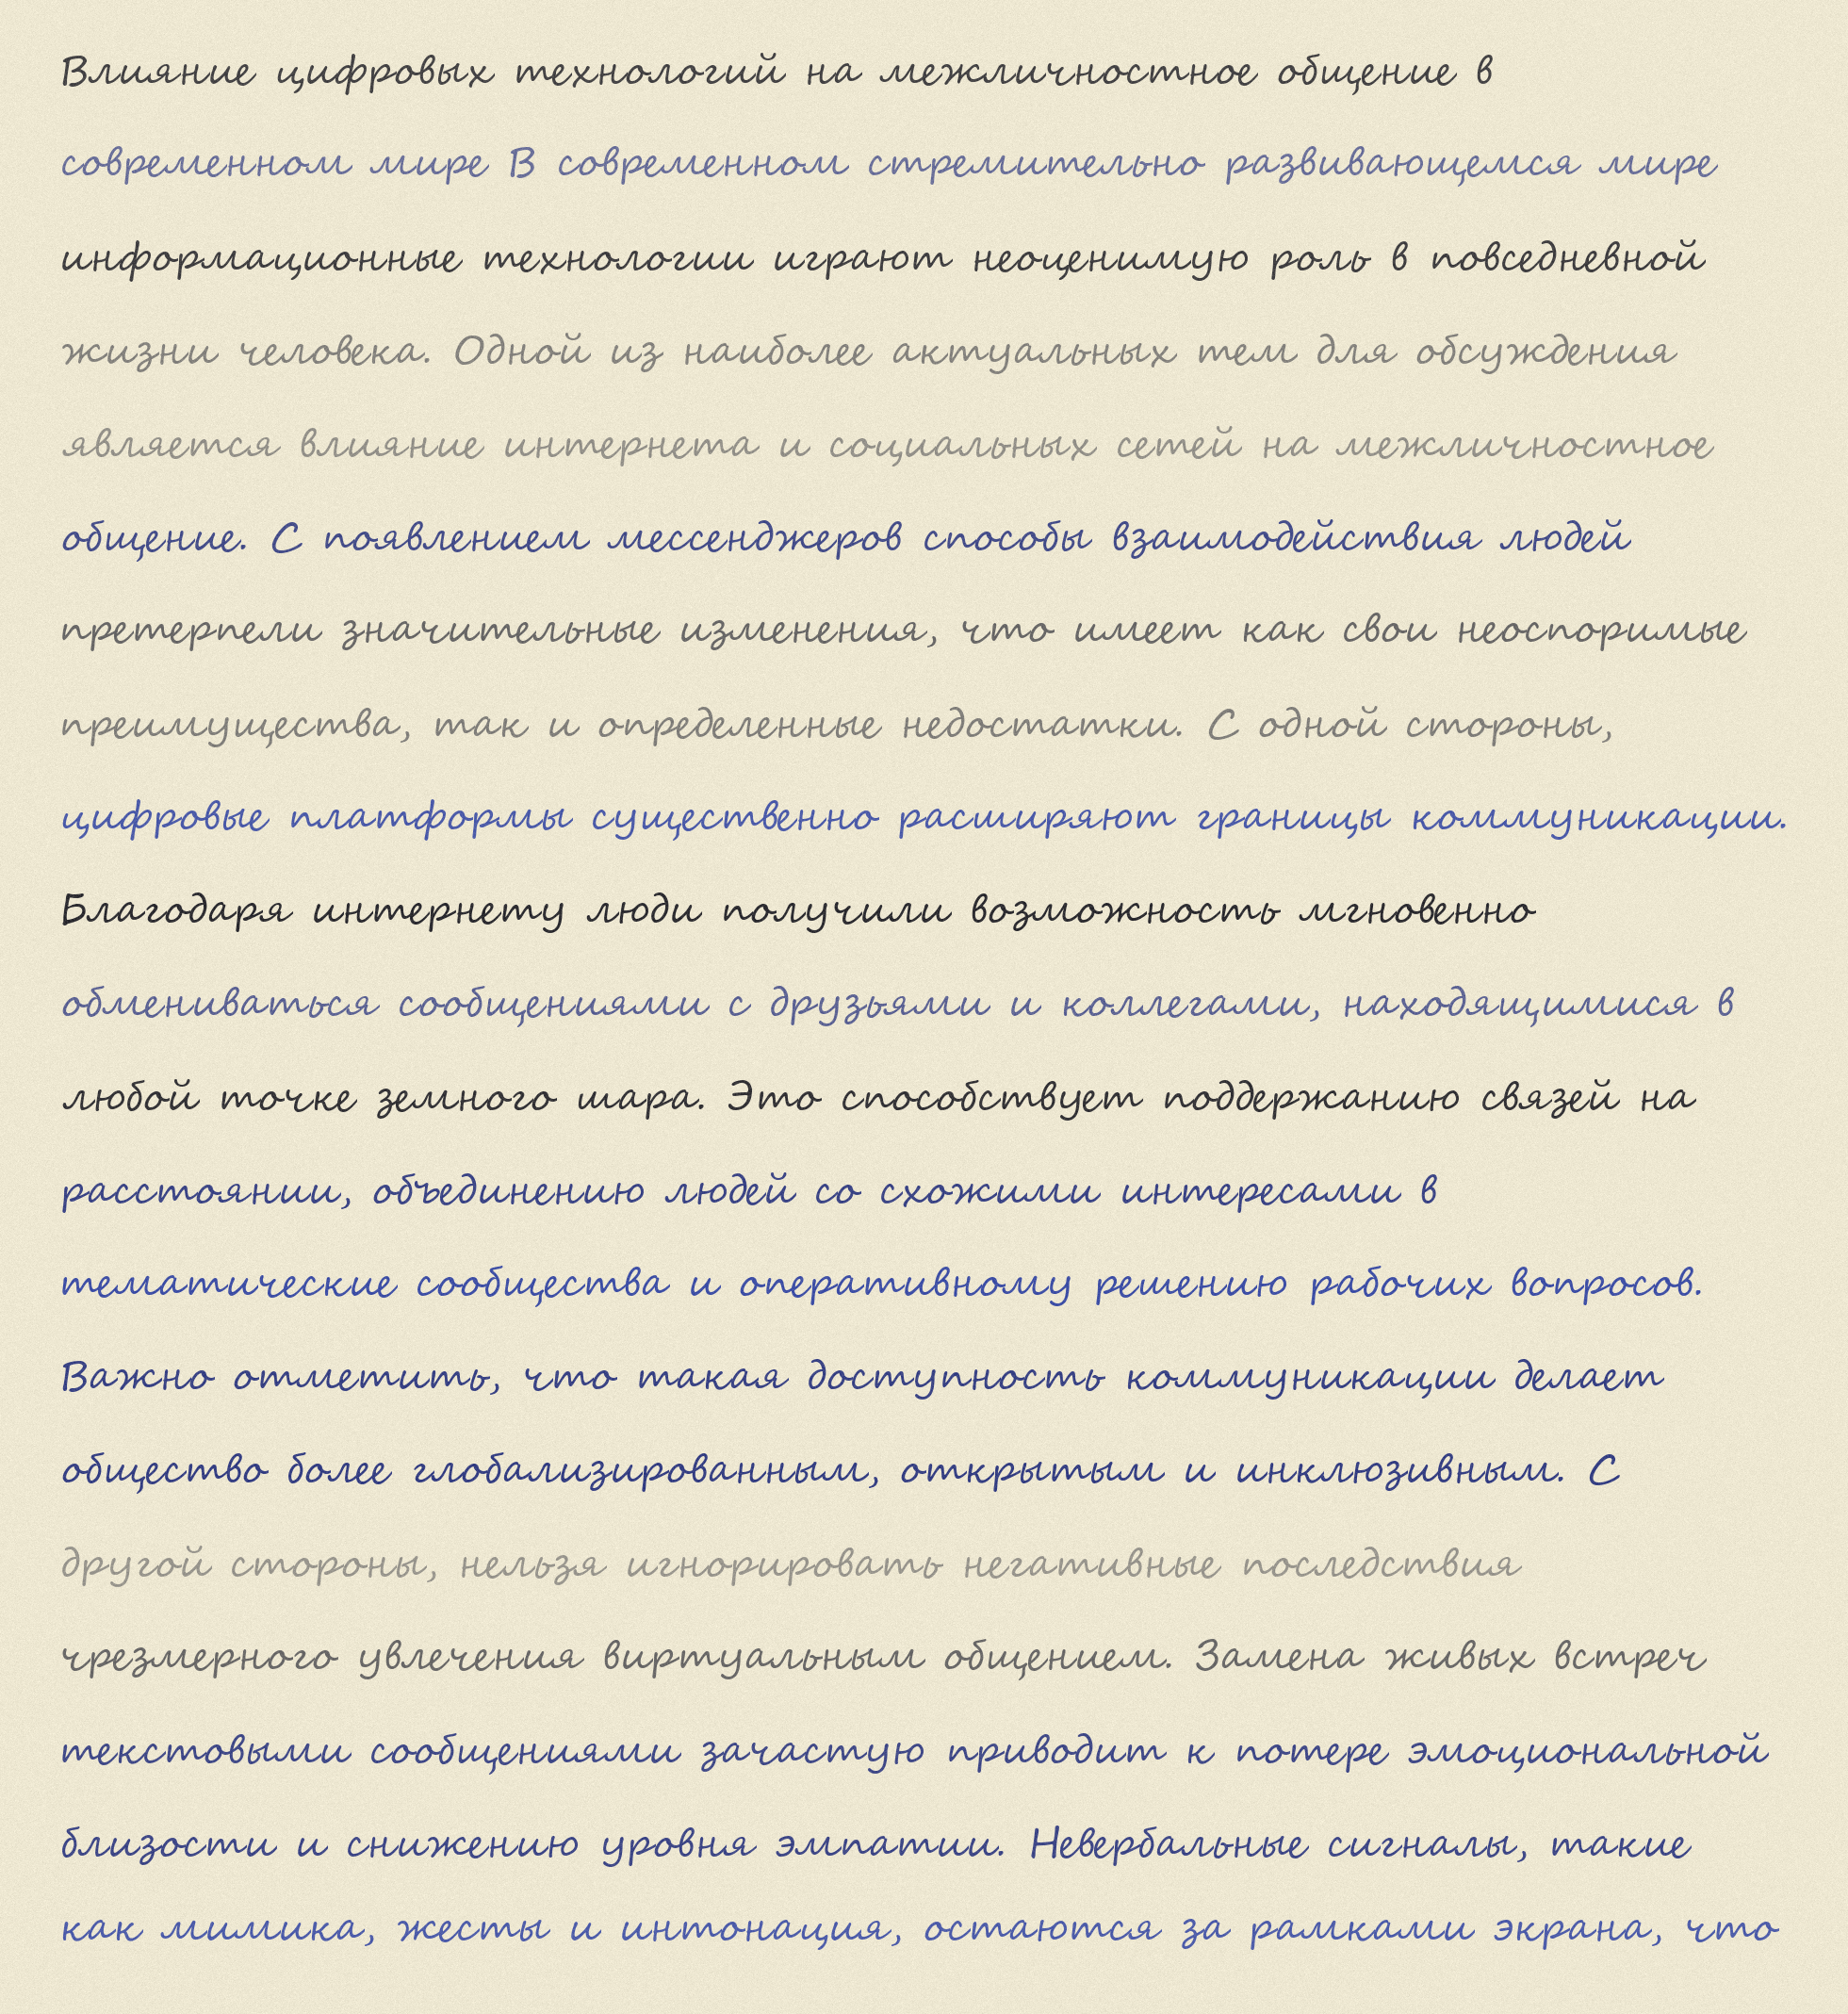

In [11]:
import sys, random, textwrap
from pathlib import Path

sys.path.insert(0, "recognition/")

import numpy as np
from PIL import Image
from omegaconf import OmegaConf
from src.synth import HandwrittenLineGenerator, make_generator

cfg = OmegaConf.load("recognition/configs/pretrain_stage2.yaml")
gen = HandwrittenLineGenerator.from_dirs(
    ru_font_dirs=list(cfg.data.ru_font_dirs),
    en_font_dirs=list(cfg.data.en_font_dirs),
    synth_overrides=cfg.synth,
)

TXT   = "data/txt_texts/text2.txt"
LANG  = "ru"
NLINES, WRAP, SIZE, STEP, SEED = 21, 65, 42, 0, 2   # строк на странице / символов в строке / кегль / эффекты / seed

raw   = [ln.strip() for ln in Path(TXT).read_text(encoding="utf-8").splitlines() if ln.strip()]
start = random.Random(SEED).randrange(len(raw))
block = " ".join(raw[start:start + NLINES * 3])       # случайный кусок текста
lines = textwrap.wrap(block, WRAP)[:NLINES]           # перенос по словам в строки фикс. ширины

rng   = make_generator(SEED, 0, 0)
t     = gen.difficulty(STEP)
entry = gen.fonts.sample(rng, LANG)                   # один почерк на страницу
font  = gen.fonts.get(entry, SIZE)

inks = [gen.renderer.render(entry.filter(ln).strip(), font, rng, t)[0] for ln in lines]
inks = [k for k in inks if k is not None and k.width > 1 and k.height > 1]

mx, my, gap = 60, 50, int(SIZE * 1.0)
line_h = max(k.height for k in inks)
W = 2 * mx + max(k.width for k in inks)
H = 2 * my + len(inks) * (line_h + gap) - gap
page = gen.paper.make((W, H), rng, t).convert("RGBA")

y = my
for k in inks:
    page.alpha_composite(k, (mx, y)); y += line_h + gap

img = Image.fromarray(gen.effects(np.asarray(page.convert("RGB")), rng, t))
img.save("data/synth/image1.jpg")
img

In [14]:
from pathlib import Path
from infer_page import LineDetector, LineRecognizer, recognize_page, visualize, show_lines, pick_device

device = pick_device("cuda")
det = LineDetector("detection/config.yaml", "detection/outputs/dbnetpp_r18_hwr/best.pt", device)
rec = LineRecognizer("recognition/configs/finetune.yaml", "recognition/outputs/trocr_small_bi_finetune_with_hwr200_cleaned/best", device, num_beams=4)

[det] loaded best.pt (epoch 73, EMA weights)


Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

[rec] loaded recognition/outputs/trocr_small_bi_finetune_with_hwr200_cleaned/best (beams=4, max_len=128)


Влияние цифровых технологий на межличностное общение в современном мире
В современном стремительно развивающемся мире информационные технологии играют неоценимую роль в повседневной жизни человека. Одной из наиболее актуальных тем для обсуждения является влияние интернета и социальных сетей на межличностное общение. С появлением мессенджеров способы взаимодействия людей претерпели значительные изменения, что имеет как свои неоспоримые преимущества, так и определенные недостатки.
С одной стороны, цифровые платформы существенно расширяют границы коммуникации. Благодаря интернету люди получили возможность мгновенно обмениваться сообщениями с друзьями и коллегами, находящимися в любой точке земного шара. Это способствует поддержанию связей на расстоянии, объединению людей со схожими интересами в тематические сообщества и оперативному решению рабочих вопросов. Важно отметить, что такая доступность коммуникации делает общество более глобализированным, открытым и инклюзивным.
С другой стороны

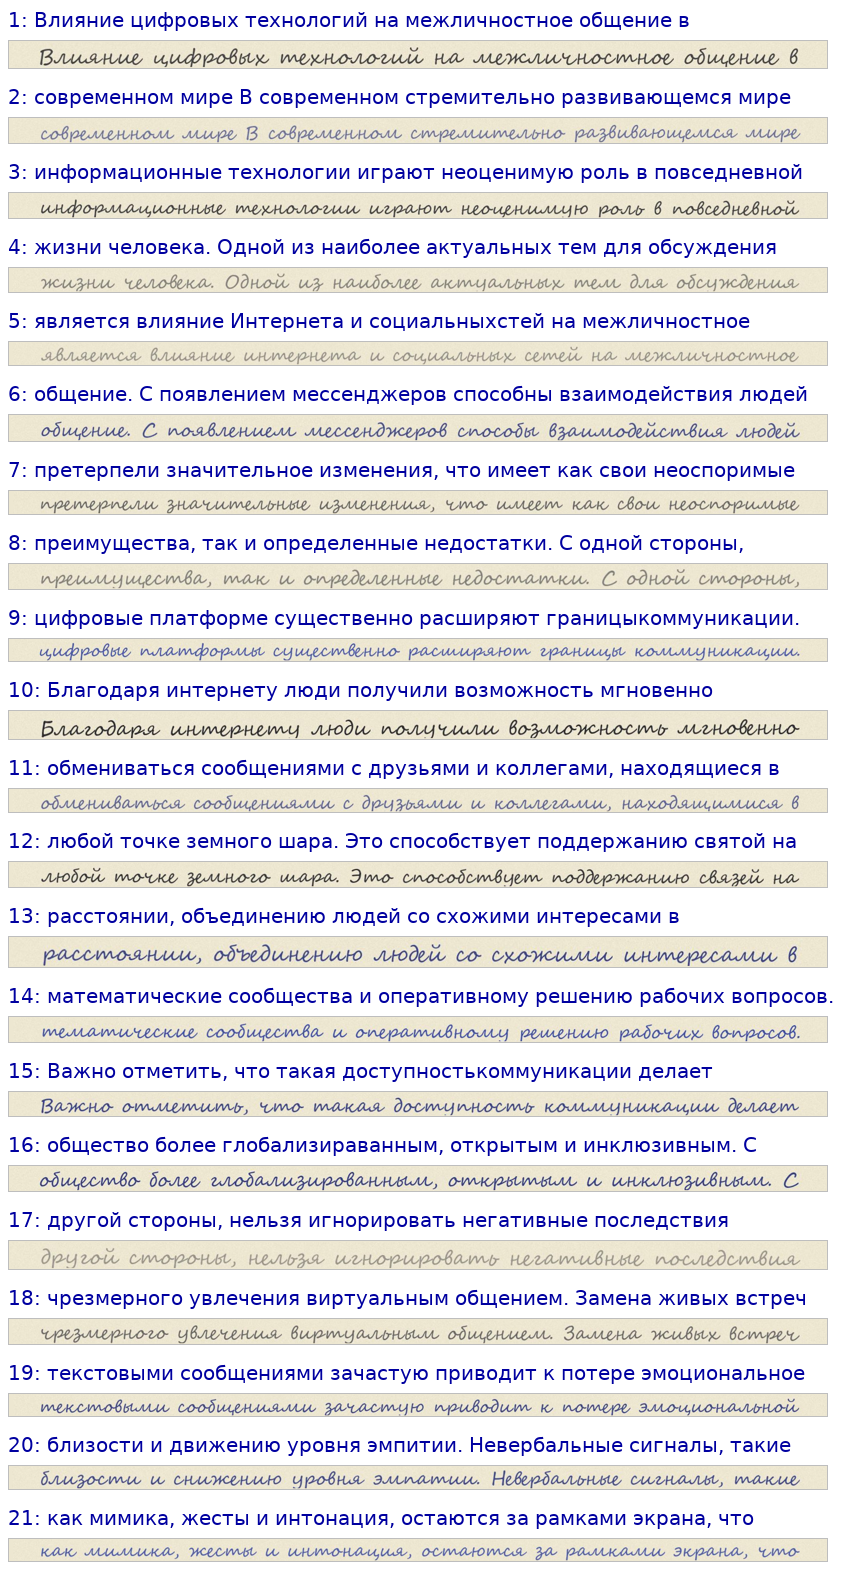

In [15]:
image = Path("data/synth/image1.jpg")
text_after_ocr, lines, crops = recognize_page(image, det, rec, return_crops=True)
print(text)

show_lines(crops, lines)

In [16]:
from ap_res_external_docchecker_protos.client import Client as CheckerClient
from ap_res_utils.guid_utils import uuid_to_hi_lo, doc_node_id_to_uuid, hi_lo_to_uuid
import uuid

CHECKER_URL = "https://elibrary-paraphrase.internal.k8s.antiplagiat.ru/"
paraphrase_client = CheckerClient([CHECKER_URL])

DOCHECKER_URL = 'https://docchecker-elib-1.internal.k8s.antiplagiat.ru/'
dochecker_client = CheckerClient([DOCHECKER_URL])

predict = dochecker_client.check_text(request_guid=[1,1],
                            doc_guid=[1,1],
                            text=text_after_ocr,
                            text_langs=['ru'],
                            collection_langs=['ru'],
                            max_sources_count=10,
                            index_usage_mode='Full',
                            pair_comparing_usage='StrictFuzzy',
                            data_range=(1, (365*24*60*60)*3000))

predict_sources = [str(hi_lo_to_uuid(int(src['SrcId']['Hi']), int(src['SrcId']['Lo']))) for src in predict['Sources']]
pr_percent = predict['Originality']

predict_paraphrase_client = paraphrase_client.check_text(
       request_guid=[1,1],
        doc_guid=[1,1],
        text=text_after_ocr,
        text_langs=['ru'],
        collection_langs=['ru'],
        )

In [17]:
predict

{'Originality': 1.0,
 'RequestId': {'Hi': '1', 'Lo': '1'},
 'Statistics': {'FullTime': '0.443240900s',
  'WaitInQueue': '0s',
  'SearchByIndex': '0.441473800s',
  'LoadMetadata': '0s',
  'LoadTexts': '0s',
  'CompareTexts': '0s',
  'ProcessText': '0.001685900s',
  'ProcessCharsCount': 1297,
  'LoadTextsBatches': []},
 'Sources': []}

In [18]:
predict_paraphrase_client

{'Originality': 1.0, 'RequestId': {'Hi': '1', 'Lo': '1'}, 'Sources': []}

In [19]:
from ap_res_nlp_machinegenerated_protos.client import Client as SampleClient
client_machinegen = SampleClient(["https://entrypoint-machinegenerated.internal.k8s.antiplagiat.ru"])
sample_metadata = (("key1", "query1"),)
client_machinegen.check_text("test", text_after_ocr, "ru", threshold=0.98)

[(0, 1297)]